# Neural PDE Laboratory · 05
## Reaction–diffusion patterns

Experiments **9** of the laboratory. This notebook is self-contained:
run it in a fresh kernel; no earlier notebook or saved result is required.

[All seven notebooks](Neural_PDE_Laboratory.ipynb) · [Setup and guide](NOTEBOOK_README.md)

Install `experiments/requirements-notebook.txt`, then select **Restart Kernel and
Run All Cells**. The supplied static plots and diagnostics can be read on GitHub.
Interactive explorers are separate, self-contained HTML files in `notebook_outputs/`;
download that folder and open `index.html` in a browser, or regenerate them locally.

Python 3.11+; CPU / float64. Set `RUN_MODE = "thorough"` for longer training runs.

**Notation:** $u$ is the reference state, $u_\theta$ the neural state,
$r_\theta=\mathcal L u_\theta-f$, $\mathcal J$ a continuous residual loss,
$\widehat{\mathcal J}$ its numerical approximation, and $\mathcal E$ an energy.
A hat indicates sampling or quadrature. We check solution error separately from training loss.

In [1]:
# Uncomment only if these packages are missing, then restart the kernel.
# %pip install "numpy>=2.0" scipy matplotlib "torch>=2.2" "plotly>=5.24,<7" ipython

In [2]:
from pathlib import Path
import copy, io, json, math, platform, time
import numpy as np
import scipy
from scipy.linalg import solve_banded
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import torch
from torch import nn
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, Markdown, Image

RUN_MODE = "quick"               # "quick" or "thorough"
SEED = 7
OUTPUT_DIR = Path.cwd() / "notebook_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
NOTEBOOK_START = time.perf_counter()
metrics = []
FIGURE_NAMES, INTERACTIVE_NAMES = [], []
assert RUN_MODE in {"quick", "thorough"}
torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
torch.manual_seed(SEED)
np.random.seed(SEED)
BUDGET = {"adam_1d": 900, "lbfgs_1d": 180, "adam_2d": 1100,
          "lbfgs_2d": 260, "boundary_adam": 900}
if RUN_MODE == "thorough":
    BUDGET = {key: 2 * value for key, value in BUDGET.items()}
versions = {"python": platform.python_version(), "numpy": np.__version__,
            "scipy": scipy.__version__, "matplotlib": matplotlib.__version__,
            "torch": torch.__version__, "plotly": plotly.__version__}
print(json.dumps(versions, indent=2))
print(f"CPU / float64 / seed {SEED} / {RUN_MODE} mode")

{
  "python": "3.13.9",
  "numpy": "2.4.2",
  "scipy": "1.17.0",
  "matplotlib": "3.10.8",
  "torch": "2.10.0",
  "plotly": "6.9.0"
}
CPU / float64 / seed 7 / quick mode


## Reading and saving the plots

Static figures are saved as PNG and PDF and embedded in this notebook. Interactive
plots are saved as offline HTML files: open their links locally to rotate, zoom,
and animate them. GitHub displays the static figures without executing JavaScript.

In [3]:
palette = {"navy": "#10243A", "teal": "#00A6A6", "orange": "#F28C45",
           "pink": "#DC4778", "blue": "#4878D0", "ink": "#183449", "muted": "#63788A"}
plt.rcParams.update({
    "figure.facecolor": "#F7FAFC", "axes.facecolor": "#F7FAFC",
    "axes.edgecolor": "#CAD6DF", "axes.labelcolor": palette["ink"],
    "text.color": palette["ink"], "xtick.color": palette["muted"],
    "ytick.color": palette["muted"], "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#DCE5EB", "grid.alpha": 0.65,
    "lines.linewidth": 2.3, "figure.dpi": 110, "savefig.dpi": 170,
    "legend.frameon": False, "font.family": "DejaVu Sans",
    "axes.prop_cycle": matplotlib.cycler(color=[palette[k] for k in
                                  ["teal", "orange", "pink", "blue", "navy"]]),
})
sea_cmap = LinearSegmentedColormap.from_list("sea", ["#10243A", "#146F88", "#00BBB0", "#F9D879"])
wave_scale = [[0, "#153F7C"], [.25, "#21A9B5"], [.5, "#F7FAFC"],
              [.75, "#FFB16E"], [1, "#C93663"]]

def style_3d(ax, title=None):
    if title:
        ax.set_title(title)
    ax.view_init(elev=28, azim=-128)
    ax.set_box_aspect((1, 1, .65))
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.fill = False
        axis._axinfo["grid"]["color"] = (0.78, 0.84, 0.88, 0.35)
    ax.tick_params(labelsize=8, pad=1)

def save_figure(fig, name):
    if name not in FIGURE_NAMES:
        FIGURE_NAMES.append(name)
    fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight")
    fig.savefig(OUTPUT_DIR / f"{name}.pdf", bbox_inches="tight")
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=130, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

def show_interactive(fig, name):
    if name not in INTERACTIVE_NAMES:
        INTERACTIVE_NAMES.append(name)
    fig.update_layout(template="plotly_dark", paper_bgcolor="#10243A",
                      plot_bgcolor="#10243A", font=dict(family="Arial", size=13),
                      margin=dict(l=40, r=55, t=130, b=75), height=680)
    fig.update_layout(title=dict(x=.035, y=.97, xanchor="left", font=dict(size=19)))
    for menu in fig.layout.updatemenus:
        menu.update(y=1.04, yanchor="bottom", x=0, xanchor="left",
                    bgcolor="#E5EFF5", bordercolor="#9FB8CA",
                    font=dict(color="#10243A", size=12))
    fig.update_scenes(bgcolor="#10243A",
        xaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        yaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"),
        zaxis=dict(backgroundcolor="#10243A", gridcolor="#31506C"))
    config = {"displaylogo": False, "responsive": True}
    fig.write_html(OUTPUT_DIR / f"{name}.html", include_plotlyjs=True,
                   full_html=True, config=config, auto_play=False)
    # Keep notebook previews small: JavaScript and animation data live in HTML.
    relative = (OUTPUT_DIR / f"{name}.html").relative_to(Path.cwd()).as_posix()
    display(Markdown(f"[Open interactive explorer]({relative}) — "
                     "open locally in a browser; GitHub previews show the static plots."))

def grad_scalar(u, x):
    return torch.autograd.grad(u.sum(), x, create_graph=True)[0]

def mlp(input_dim, width=32, depth=2):
    layers = [nn.Linear(input_dim, width), nn.Tanh()]
    for _ in range(depth - 1):
        layers.extend([nn.Linear(width, width), nn.Tanh()])
    return nn.Sequential(*layers, nn.Linear(width, 1))

def train_model(model, objective, adam_steps, lbfgs_steps=0, diagnostic=None):
    """Log each objective evaluation, including repeated L-BFGS closure calls."""
    start = time.perf_counter()
    history = {"evaluation": [], "loss": [], "error_eval": [], "error": []}
    evaluations = 0
    opt = torch.optim.Adam(model.parameters(), lr=2e-3)
    def evaluate():
        nonlocal evaluations
        value = objective()
        evaluations += 1
        history["evaluation"].append(evaluations)
        history["loss"].append(value.detach().item())
        return value
    for step in range(adam_steps):
        opt.zero_grad(set_to_none=True)
        loss = evaluate()
        loss.backward()
        opt.step()
        if diagnostic is not None and (step == 0 or (step + 1) % 100 == 0):
            history["error_eval"].append(evaluations)
            history["error"].append(diagnostic())
    if lbfgs_steps:
        opt = torch.optim.LBFGS(model.parameters(), max_iter=lbfgs_steps,
                 max_eval=2*lbfgs_steps, history_size=40, line_search_fn="strong_wolfe",
                 tolerance_grad=1e-10, tolerance_change=1e-13)
        def closure():
            opt.zero_grad(set_to_none=True)
            value = evaluate()
            value.backward()
            return value
        opt.step(closure)
    if diagnostic is not None:
        history["error_eval"].append(evaluations)
        history["error"].append(diagnostic())
    history["seconds"] = time.perf_counter() - start
    return history

## 9 · Patterns in a reaction–diffusion system

For this experiment, we use **finite differences** to solve the Gray–Scott system.
Diffusion and reaction produce spatial patterns:
$$a_t=D_a\Delta a-ab^2+F(1-a),\qquad
b_t=D_b\Delta b+ab^2-(F+k)b.$$
We use periodic boundaries on $[0,96)^2$, grid spacing $h=1$, a five-point Laplacian,
and explicit Euler with $\Delta t=0.9$. The diffusion-only CFL limit is
$\Delta t\le h^2/(4\max(D_a,D_b))$; satisfying it does not by itself control the
nonlinear reaction error. We check a shorter run with half the time step as a diagnostic.

All three runs start from the same perturbed central patch; only $(F,k)$ changes.
The plotted height is the computed concentration $b$ on a **2D spatial domain**.

Background: [Pearson, *Complex Patterns in a Simple System* (1993)](https://doi.org/10.1126/science.261.5118.189).

Three pattern simulations: 4.8 s
Short-run difference at t=360, dt vs dt/2: 0.42%
This time-step comparison does not estimate spatial error or certify long-time patterns.


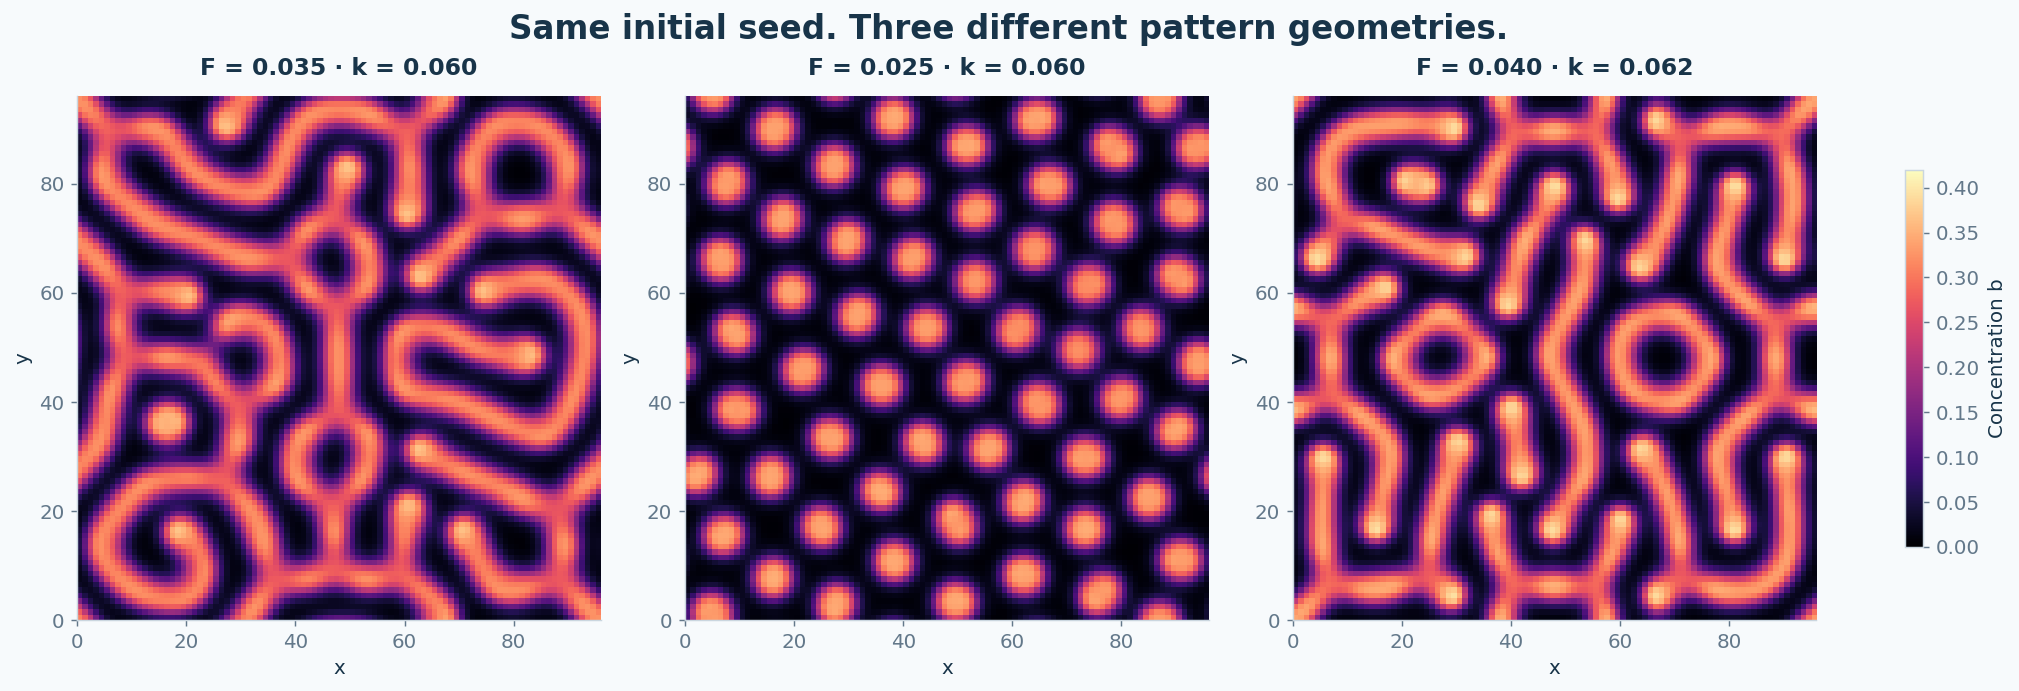

In [4]:
rd_n, rd_h, rd_dt = 96, 1., .9
rd_Da, rd_Db = .16, .08
rd_rng = np.random.default_rng(92)
rd_a0, rd_b0 = np.ones((rd_n, rd_n)), np.zeros((rd_n, rd_n))
rd_a0[39:57,39:57], rd_b0[39:57,39:57] = .5, .25
rd_a0 += .01*rd_rng.standard_normal(rd_a0.shape)
rd_b0 += .01*rd_rng.random(rd_b0.shape)

def rd_laplacian(z):
    return (np.roll(z,1,0)+np.roll(z,-1,0)+np.roll(z,1,1)+np.roll(z,-1,1)-4*z)/rd_h**2

def rd_simulate(feed, kill, steps=6500, dt=rd_dt, record=False):
    a, b = rd_a0.copy(), rd_b0.copy()
    frames, times = [b.copy()], [0.]
    for step in range(steps):
        reaction = a*b*b
        da = rd_Da*rd_laplacian(a)-reaction+feed*(1-a)
        db = rd_Db*rd_laplacian(b)+reaction-(feed+kill)*b
        a, b = a+dt*da, b+dt*db
        if record and (step+1)%130 == 0:
            frames.append(b.copy()); times.append((step+1)*dt)
    assert np.isfinite(a).all() and np.isfinite(b).all()
    assert a.min() > -1e-8 and b.min() > -1e-8
    return a, b, np.asarray(frames), np.asarray(times)

assert rd_dt < rd_h**2/(4*max(rd_Da, rd_Db))
rd_start = time.perf_counter()
rd_parameters = [(0.035,0.060), (0.025,0.060), (0.040,0.062)]
rd_results = [rd_simulate(f,k,record=(i==0)) for i,(f,k) in enumerate(rd_parameters)]
rd_coarse = rd_simulate(*rd_parameters[0], steps=400, dt=rd_dt)[1]
rd_fine = rd_simulate(*rd_parameters[0], steps=800, dt=rd_dt/2)[1]
rd_time_difference = np.linalg.norm(rd_coarse-rd_fine)/np.linalg.norm(rd_fine)
print(f"Three pattern simulations: {time.perf_counter()-rd_start:.1f} s")
print(f"Short-run difference at t=360, dt vs dt/2: {rd_time_difference:.2%}")
print("This time-step comparison does not estimate spatial error or certify long-time patterns.")

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.2), layout="constrained")
for ax, (feed,kill), (_,b,_,_) in zip(axes, rd_parameters, rd_results):
    im = ax.imshow(b, origin="lower", extent=(0,96,0,96), cmap="magma", vmin=0, vmax=.42)
    ax.set(title=f"F = {feed:.3f} · k = {kill:.3f}", xlabel="x", ylabel="y")
fig.colorbar(im, ax=axes, shrink=.72, label="Concentration b")
fig.suptitle("Same initial seed. Three different pattern geometries.", fontsize=18, weight="bold")
save_figure(fig, "09_reaction_patterns")

In [5]:
rd_frames, rd_times = rd_results[0][2:]
rd_coords = np.arange(rd_n)[::2]
rd_X, rd_Y = np.meshgrid(rd_coords, rd_coords)
rd_fig = go.Figure(data=[go.Surface(x=rd_X, y=rd_Y, z=rd_frames[0,::2,::2],
                   colorscale="Magma", cmin=0, cmax=.42, colorbar=dict(title="b"))],
    frames=[go.Frame(name=str(i), data=[go.Surface(z=b[::2,::2])]) for i,b in enumerate(rd_frames)])
rd_fig.update_layout(title="Pattern formation · a 2D chemical field becomes a landscape",
    scene=dict(xaxis_title="x", yaxis_title="y", zaxis=dict(title="b",range=[0,.43]),
               aspectratio=dict(x=1,y=1,z=.45), uirevision="reaction"),
    updatemenus=[dict(type="buttons", direction="left", x=0, y=1.1, buttons=[
        dict(label="▶ Grow patterns",method="animate",args=[None,dict(frame=dict(duration=75,redraw=True),
             transition=dict(duration=0),fromcurrent=True)]),
        dict(label="Pause",method="animate",args=[[None],dict(mode="immediate",
             frame=dict(duration=0,redraw=False),transition=dict(duration=0))])])],
    sliders=[dict(currentvalue=dict(prefix="Time t = "), steps=[dict(label=f"{t:.0f}",method="animate",
        args=[[str(i)],dict(mode="immediate",frame=dict(duration=0,redraw=True),
        transition=dict(duration=0))]) for i,t in enumerate(rd_times)])])
show_interactive(rd_fig, "09_reaction_interactive")

[Open interactive explorer](notebook_outputs/09_reaction_interactive.html) — open locally in a browser; GitHub previews show the static plots.

**Try:** halve the grid spacing while keeping the physical domain fixed; rescale the
Laplacian and time step consistently. Refinement changes the cost and may alter the
pattern. What would be a meaningful validation metric for a PINN trained on this system:
pointwise concentration, pattern wavelength, a time-dependent quantity of interest, or all three?

## Save this notebook's results

This cell records versions, settings, diagnostics and computed fields, and builds a
local gallery. Report filenames include this notebook's part number, so notebooks
can run independently in any order without overwriting each other's reports.

In [6]:
# Keep reports separate so running one notebook cannot replace another's results.
PART = '05_reaction_diffusion'
summary_metrics = list(metrics)

report = dict(part=PART, versions=versions, run_mode=RUN_MODE, seed=SEED, budgets=BUDGET,
    device="cpu", dtype=str(torch.get_default_dtype()), settings=dict(seed=92, steps=6500, dt=rd_dt, grid=rd_n, parameters=rd_parameters, time_step_difference=float(rd_time_difference)),
    static_figures=FIGURE_NAMES, interactive_figures=INTERACTIVE_NAMES,
    metrics=summary_metrics, elapsed_seconds=time.perf_counter()-NOTEBOOK_START)
(OUTPUT_DIR / f"run_summary_{PART}.json").write_text(json.dumps(report, indent=2))
np.savez_compressed(OUTPUT_DIR / f"computed_fields_{PART}.npz", reaction_b=np.stack([r[1] for r in rd_results]))

from html import escape
cards = []
for name in FIGURE_NAMES:
    title = escape(name.replace("_", " ").title())
    cards.append(f'<figure><a href="{name}.png"><img src="{name}.png" alt="{title}"></a>'
                 f'<figcaption>{title} · <a href="{name}.pdf">PDF</a></figcaption></figure>')
links = "".join(f'<li><a href="{name}.html">{escape(name.replace("_", " ").title())}</a></li>'
                for name in INTERACTIVE_NAMES)
page = ('<!doctype html><html lang="en"><meta charset="utf-8">'
        '<meta name="viewport" content="width=device-width, initial-scale=1">'
        '<title>Neural PDE Laboratory</title><style>'
        'body{font-family:system-ui;color:#273442;max-width:1100px;margin:auto;padding:32px}'
        'img{max-width:100%}figure{margin:32px 0}a{color:#4d708a}</style>'
        f'<h1>Neural PDE Laboratory · {escape(PART)}</h1><ul>' + links + '</ul>' + "".join(cards) + '</html>')
(OUTPUT_DIR / f"index_{PART}.html").write_text(page)
print(f"Completed in {report['elapsed_seconds']:.1f} seconds.")
print(f"Saved {len(FIGURE_NAMES)} figure sets and {len(INTERACTIVE_NAMES)} interactive explorers.")
print(f"Reports: run_summary_{PART}.json, computed_fields_{PART}.npz, index_{PART}.html")
for row in summary_metrics:
    print(f"{row['experiment']:32s} relative L2 = {row['relative_l2']:.3e}")

Completed in 7.2 seconds.
Saved 1 figure sets and 1 interactive explorers.
Reports: run_summary_05_reaction_diffusion.json, computed_fields_05_reaction_diffusion.npz, index_05_reaction_diffusion.html


[Previous notebook](Neural_PDE_04_dimensions_and_geometry.ipynb) · [Laboratory index](Neural_PDE_Laboratory.ipynb) · [Next notebook](Neural_PDE_06_features_and_sampling.ipynb)